In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize

import warnings
warnings.filterwarnings('ignore')


REVIEW DATASET SAU KHI ĐÃ XỬ LÍ 

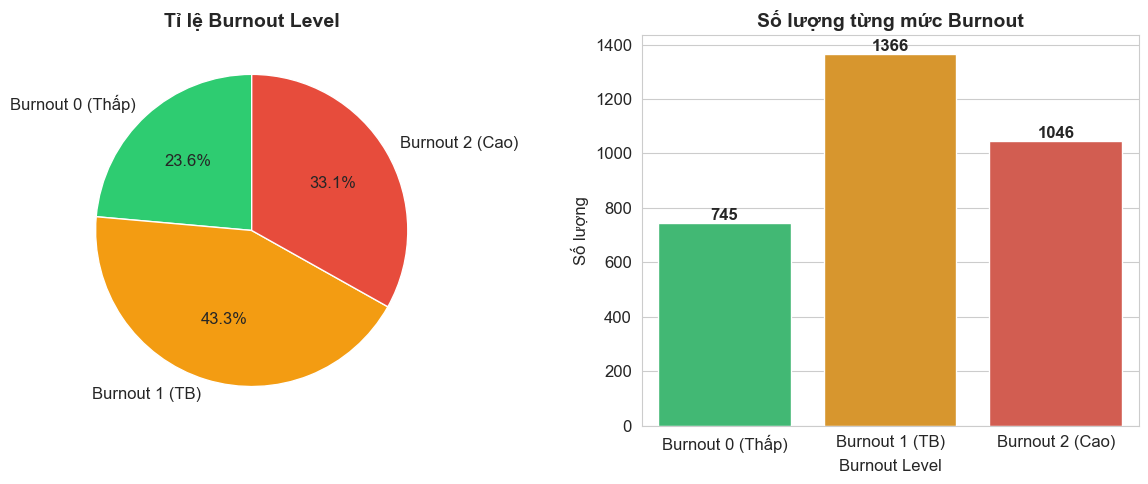

In [ ]:
df = pd.read_csv("../data/processed/clean_ds_data.csv")

# Vẽ biểu đồ
burnout_counts = df['Burnout_Level'].value_counts().sort_index()
burnout_labels = ['Burnout 0 (Thấp)', 'Burnout 1 (TB)', 'Burnout 2 (Cao)']
colors = ['#2ecc71', '#f39c12', '#e74c3c'] 


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
axes[0].pie(burnout_counts, labels=burnout_labels, autopct='%1.1f%%', 
            colors=colors, startangle=90, explode=(0, 0, 0))
axes[0].set_title('Tỉ lệ Burnout Level', fontsize=14, fontweight='bold')

# Bar chart
sns.barplot(x=burnout_labels, y=burnout_counts.values, palette=colors, ax=axes[1])
axes[1].set_title('Số lượng từng mức Burnout', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Burnout Level')
axes[1].set_ylabel('Số lượng')
for i, v in enumerate(burnout_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


CHỌN ĐẶC TRƯNG CẦN DÙNG VÀ TÁCH DATATSET


In [ ]:
features = [
    # Demographic
    'Age', 
    'Gender_Male', 'Gender_Non-binary', 'Gender_Prefer not to say',
    
    # Work-related
    'Hours_Per_Week', 
    'Work_Life_Balance_Score',
    'Work_Arrangement_Onsite', 'Work_Arrangement_Remote',
    
    # Industry & Role
    'Industry_Education', 'Industry_Finance', 'Industry_Healthcare', 
    'Industry_Manufacturing', 'Industry_Marketing', 'Industry_Professional Services',
    'Industry_Retail', 'Industry_Technology',
    
    'Job_Role_Data Analyst', 'Job_Role_Data Scientist', 'Job_Role_DevOps Engineer',
    'Job_Role_HR Manager', 'Job_Role_IT Support', 'Job_Role_Operations Manager',
    'Job_Role_Other', 'Job_Role_Project Manager', 'Job_Role_Research Scientist',
    'Job_Role_Social Media Manager',
    
    # Physical symptoms 
    'has_Back Pain', 'has_Eye Strain', 'has_Neck Pain', 'has_Shoulder Pain', 'has_Wrist Pain',
    
    # Social
    'Social_Isolation_Score'
]

target = 'Burnout_Level' 

X = df[features]
y  = df[target]
print(f'Số features: {len(features)}')
print(f'Số samples: {len(X)}')

In [60]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  
)

print(f'Train set: {X_train.shape[0]} mẫu')
print(f'Valid set: {X_valid.shape[0]} mẫu')
print(f'\nTỷ lệ y_train(%):')
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))

Train set: 2525 mẫu
Valid set: 632 mẫu

Tỷ lệ y_train(%):
Burnout_Level
0    23.60
1    43.25
2    33.15
Name: proportion, dtype: float64


HUẤN LUYỆN MÔ HÌNH RANDOM FOREST

In [77]:
rf_model = RandomForestClassifier(
    n_estimators=200,     
    max_depth=10,         
    min_samples_split=10,  
    min_samples_leaf=5,    
    class_weight='balanced',
    random_state=42,
    n_jobs=-1            
)

# Huấn luyện
rf_model.fit(X_train, y_train)
print('Huấn luyện mô hình random forest hoàn tất!')

Huấn luyện mô hình random forest hoàn tất!


ĐÁNH GIÁ MÔ HÌNH RANDOM FOREST

In [ ]:
# Dự báo trên tập X_valid
y_pred = rf_model.predict(X_valid)

acc = accuracy_score(y_valid, y_pred)
f1_macro = f1_score(y_valid, y_pred, average='macro')
f1_weighted = f1_score(y_valid, y_pred, average='weighted')

print('=' * 50)
print('KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH')
print('=' * 50)
print(f'  Accuracy       : {acc:.4f} ({acc*100:.2f}%)')
print(f'  F1 (macro)     : {f1_macro:.4f}')
print(f'  F1 (weighted)  : {f1_weighted:.4f}')
print('=' * 50)
print()
print('Classification Report:')
print(classification_report(
    y_valid, y_pred,
    target_names=['Thấp (0)', 'Trung bình (1)', 'Cao (2)']
))

KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH
  Accuracy       : 0.3718 (37.18%)
  F1 (macro)     : 0.3712
  F1 (weighted)  : 0.3640

Classification Report:
                precision    recall  f1-score   support

      Thấp (0)       0.31      0.47      0.37       149
Trung bình (1)       0.40      0.24      0.30       274
       Cao (2)       0.41      0.47      0.44       209

      accuracy                           0.37       632
     macro avg       0.37      0.39      0.37       632
  weighted avg       0.38      0.37      0.36       632



In [ ]:
# Đánh giá theo Cross-validation 5-fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X, y, cv=cv, scoring='f1_macro', n_jobs=-1)

print(f'\nCross-Validation (5-fold) F1 macro:')
print(f'Scores: {[round(s, 4) for s in cv_scores]}')
print(f'Mean  : {cv_scores.mean():.4f}')
print(f'Std   : {cv_scores.std():.4f}')


Cross-Validation (5-fold) F1 macro:
Scores: [np.float64(0.3809), np.float64(0.3359), np.float64(0.3968), np.float64(0.3622), np.float64(0.3683)]
Mean  : 0.3688
Std   : 0.0203


CONFUSION MATRIX

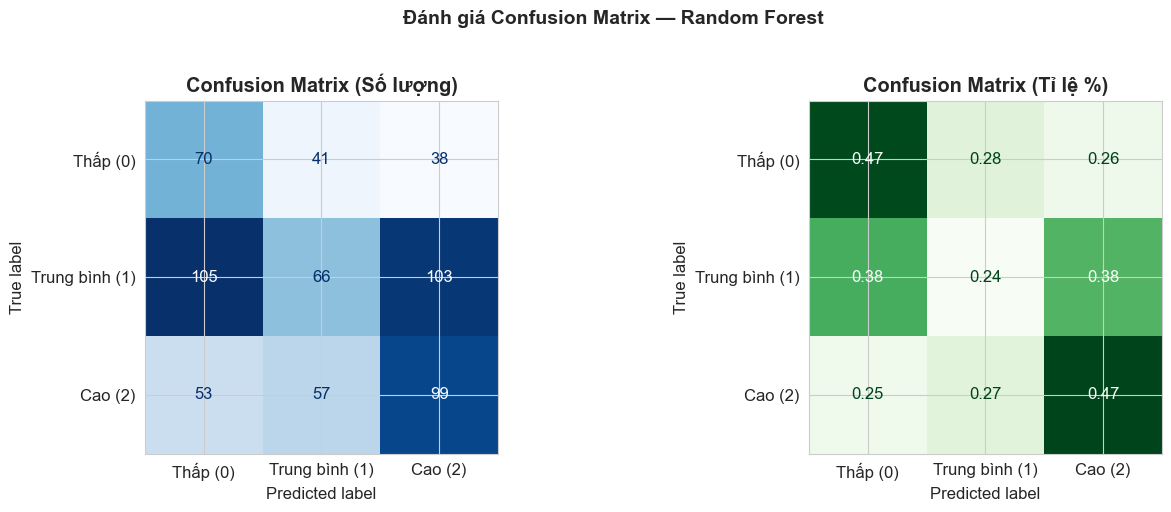

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ma trận số lượng
cm = confusion_matrix(y_valid, y_pred)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=['Thấp (0)', 'Trung bình (1)', 'Cao (2)'])
disp1.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (Số lượng)', fontweight='bold')

# Ma trận tỉ lệ %
cm_norm = confusion_matrix(y_valid, y_pred, normalize='true')
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                                display_labels=['Thấp (0)', 'Trung bình (1)', 'Cao (2)'])
disp2.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Confusion Matrix (Tỉ lệ %)', fontweight='bold')

plt.suptitle('Đánh giá Confusion Matrix — Random Forest', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

FEATURE IMPORTANCE

In [93]:
# Lấy feature importance từ mô hình
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print('Top 15 yếu tố quan trọng nhất:')
print(feat_df.head(15).to_string(index=False))

Top 15 yếu tố quan trọng nhất:
                       Feature  Importance
                           Age    0.155525
                Hours_Per_Week    0.149161
       Work_Arrangement_Onsite    0.082625
        Social_Isolation_Score    0.074270
       Work_Life_Balance_Score    0.072170
       Work_Arrangement_Remote    0.042357
                has_Eye Strain    0.037332
                 has_Back Pain    0.036064
             has_Shoulder Pain    0.035115
                   Gender_Male    0.033129
                Job_Role_Other    0.027512
                 has_Neck Pain    0.026511
           Industry_Technology    0.023911
                has_Wrist Pain    0.022181
Industry_Professional Services    0.021893


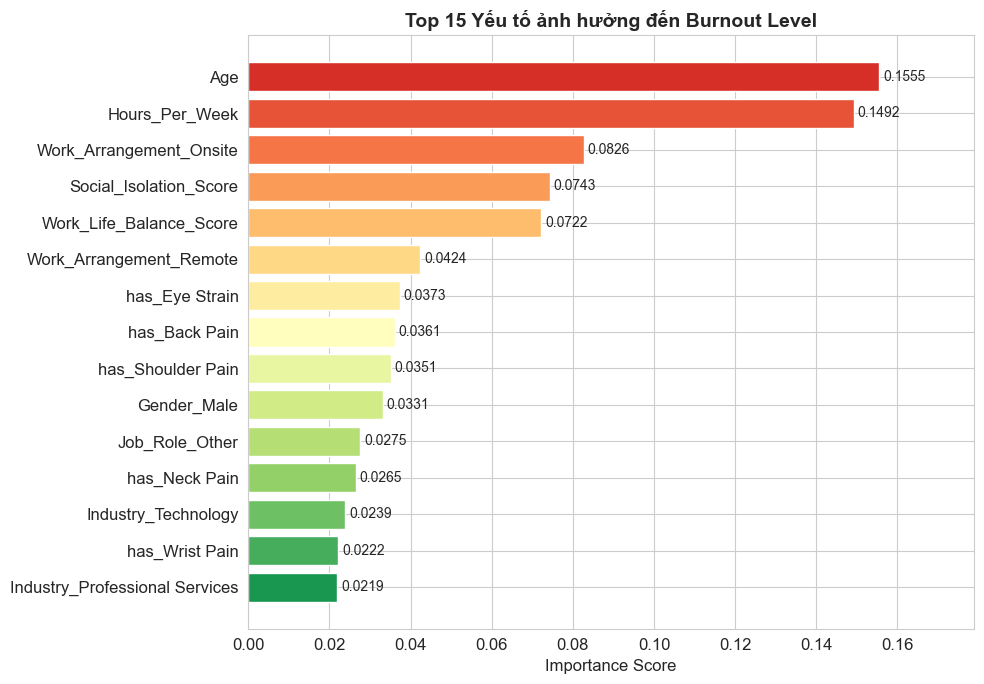

Yếu tố quan trọng nhất là "Age" (score = 0.1555)


In [97]:
# Vẽ biểu đồ Top 15
top15 = feat_df.head(15)

fig, ax = plt.subplots(figsize=(10, 7))

colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(top15)))
bars = ax.barh(top15['Feature'][::-1], top15['Importance'][::-1], color=colors)

for bar, val in zip(bars, top15['Importance'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)

ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Top 15 Yếu tố ảnh hưởng đến Burnout Level', fontsize=14, fontweight='bold')
ax.set_xlim(0, top15['Importance'].max() * 1.15)
plt.tight_layout()
plt.show()

print(f'Yếu tố quan trọng nhất là "{feat_df.iloc[0]["Feature"]}" '
      f'(score = {feat_df.iloc[0]["Importance"]:.4f})')